Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import learning_curve, StratifiedKFold, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression, LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.svm import SVC, SVR
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.ensemble import GradientBoostingClassifier, GradientBoostingRegressor
from xgboost import XGBClassifier, XGBRegressor

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 10
})
np.random.seed(42)
print('Imports done.')

Imports done.


In [2]:
import os
print(os.getcwd())
print(os.listdir())

c:\Users\jonga\OneDrive\سطح المكتب\DS230 Final project (Winter2026)\NoteBooks
['01_EDA.ipynb', '02_Preprocessing.ipynb', '03_Feature Engineering.ipynb', '04_Classification_Models.ipynb', '05_Classification_Tuning.ipynb', '06_Regression_Models.ipynb', '07_Regression_Tuning.ipynb', '08_Model_Comparison.ipynb', '09_Learning_Curves.ipynb', 'best_model_cm.png', 'calibration_curves.png', 'class_distribution.png', 'clean_data.csv', 'confusion_matrix.png', 'data', 'engineered_data.csv', 'figures', 'heatmap_lr.png', 'learning_curve_Random_Forest.png', 'learning_curve_XGBoost.png', 'mcc_comparison.png', 'model_comparison.png', 'pr_curves.png', 'results', 'roc_curves.png', 'selected_features.txt', 'tuning_final_comparison.png']


Load Data

In [3]:
df = pd.read_csv('engineered_data.csv')
df.columns = df.columns.str.strip()

median_shares = df['shares'].median()
df['popular'] = (df['shares'] > median_shares).astype(int)
df['log_shares'] = np.log1p(df['shares'])

drop_cols = ['url', 'shares', 'popular', 'log_shares']
X_all = df.drop(columns=drop_cols, errors='ignore').select_dtypes(include=[np.number])
X_all.fillna(X_all.median(), inplace=True)

X_clf = X_all.values
y_clf = df['popular'].values
X_reg = X_all.values
y_reg = df['log_shares'].values

print(f'Classification : X={X_clf.shape}  y={y_clf.shape}')
print(f'Regression     : X={X_reg.shape}  y={y_reg.shape}')


Classification : X=(38462, 68)  y=(38462,)
Regression     : X=(38462, 68)  y=(38462,)


Helper Function

In [4]:
def plot_learning_curve(ax, model, X, y, title, cv, scoring, color='steelblue'):
    train_sizes_abs, train_scores, val_scores = learning_curve(
        model, X, y,
        train_sizes=np.linspace(0.10, 1.0, 8),
        cv=cv,
        scoring=scoring,
        n_jobs=-1,
        shuffle=True,
        random_state=42
    )
    train_mean = train_scores.mean(axis=1)
    train_std  = train_scores.std(axis=1)
    val_mean   = val_scores.mean(axis=1)
    val_std    = val_scores.std(axis=1)

    ax.plot(train_sizes_abs, train_mean, 'o-', color=color, label='Train', linewidth=2)
    ax.fill_between(train_sizes_abs, train_mean - train_std, train_mean + train_std,
                    alpha=0.15, color=color)
    ax.plot(train_sizes_abs, val_mean, 's--', color='tomato', label='Validation', linewidth=2)
    ax.fill_between(train_sizes_abs, val_mean - val_std, val_mean + val_std,
                    alpha=0.15, color='tomato')

    ax.set_title(title, fontsize=10, fontweight='bold')
    ax.set_xlabel('Training Samples')
    ax.set_ylabel(scoring)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
    

    
    
    print(f"  Train Score (final): {train_mean[-1]:.4f} ± {train_std[-1]:.4f}")
    print(f"  Val   Score (final): {val_mean[-1]:.4f} ± {val_std[-1]:.4f}")
    print(f"  Gap (overfit):       {train_mean[-1] - val_mean[-1]:.4f}")

CV Strategies

In [5]:
cv_clf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_reg = KFold(n_splits=5, shuffle=True, random_state=42)

print('StratifiedKFold(5) for classification')
print('KFold(5) for regression')

StratifiedKFold(5) for classification
KFold(5) for regression


LC: Logistic Regression (L2)

  Train Score (final): 0.6429 ± 0.0007
  Val   Score (final): 0.6410 ± 0.0036
  Gap (overfit):       0.0019


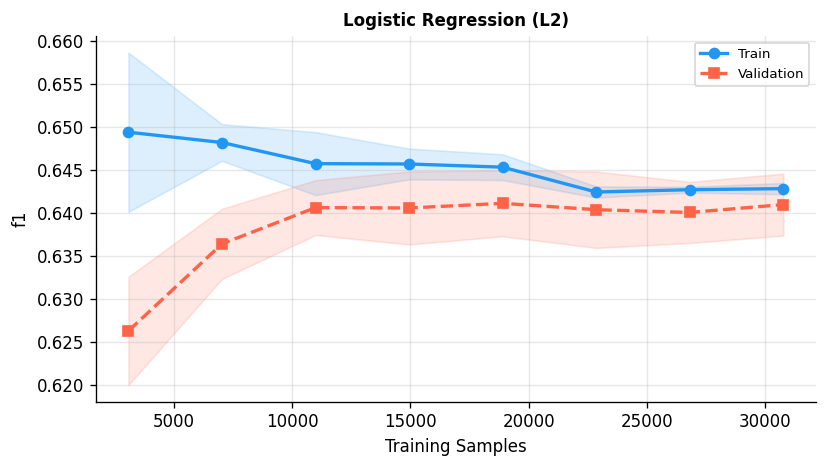

In [6]:
model = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(C=0.5, penalty='l2', max_iter=1000, random_state=42))
])

fig, ax = plt.subplots(figsize=(7, 4))
plot_learning_curve(ax, model, X_clf, y_clf,
                    title='Logistic Regression (L2)',
                    cv=cv_clf, scoring='f1', color='#2196F3')
plt.tight_layout()
plt.savefig('figures/lc_logistic_l2.png', bbox_inches='tight')
plt.show()

LC: Logistic Regression (L1)

  Train Score (final): 0.6430 ± 0.0005
  Val   Score (final): 0.6414 ± 0.0036
  Gap (overfit):       0.0015


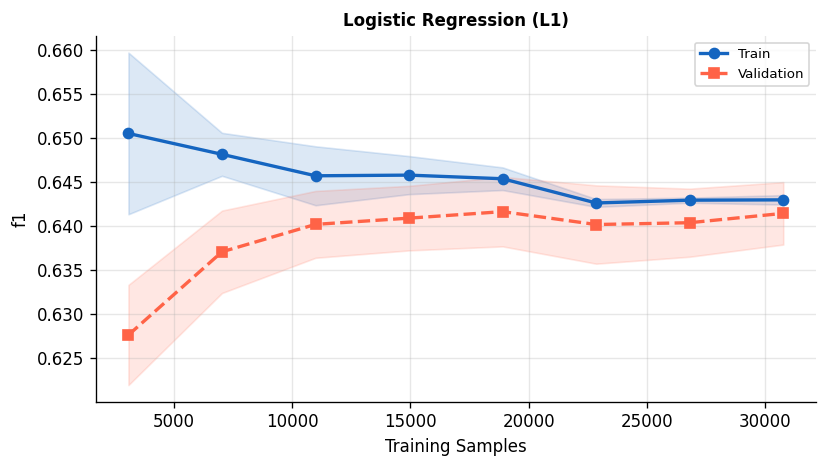

In [7]:
model = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(C=0.5, penalty='l1', solver='liblinear', max_iter=1000, random_state=42))
])

fig, ax = plt.subplots(figsize=(7, 4))
plot_learning_curve(ax, model, X_clf, y_clf,
                    title='Logistic Regression (L1)',
                    cv=cv_clf, scoring='f1', color='#1565C0')
plt.tight_layout()
plt.savefig('figures/lc_logistic_l1.png', bbox_inches='tight')
plt.show()

LC: KNN Classifier

  Train Score (final): 0.6636 ± 0.0021
  Val   Score (final): 0.6058 ± 0.0067
  Gap (overfit):       0.0578


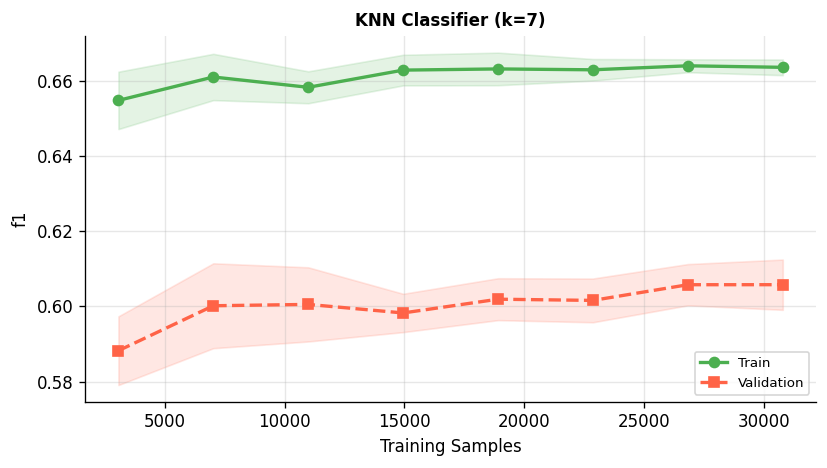

In [8]:
model = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', KNeighborsClassifier(n_neighbors=15))
])

fig, ax = plt.subplots(figsize=(7, 4))
plot_learning_curve(ax, model, X_clf, y_clf,
                    title='KNN Classifier (k=7)',
                    cv=cv_clf, scoring='f1', color='#4CAF50')
plt.tight_layout()
plt.savefig('figures/lc_knn_clf.png', bbox_inches='tight')
plt.show()

Sample

In [9]:
# Sample for SVM only — 10k rows
idx_svm = np.random.choice(len(X_clf), 10000, replace=False)
X_clf_svm = X_clf[idx_svm]
y_clf_svm = y_clf[idx_svm]

LC: SVM (Linear)

  Train Score (final): 0.6429 ± 0.0045
  Val   Score (final): 0.6338 ± 0.0093
  Gap (overfit):       0.0091


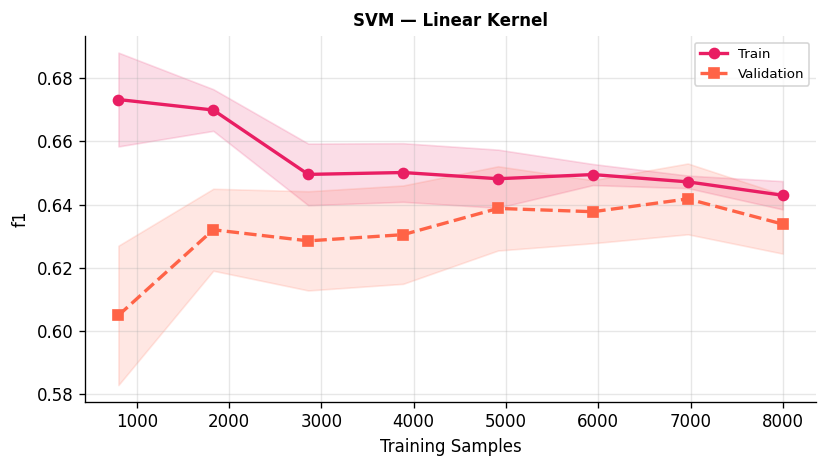

In [10]:
model = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', SVC(kernel='linear', C=0.5, probability=True, random_state=42))
])

fig, ax = plt.subplots(figsize=(7, 4))
plot_learning_curve(ax, model, X_clf_svm, y_clf_svm,
                    title='SVM — Linear Kernel',
                    cv=cv_clf, scoring='f1', color='#E91E63')
plt.tight_layout()
plt.savefig('figures/lc_svm_linear.png', bbox_inches='tight')
plt.show()

LC: SVM (RBF)

  Train Score (final): 0.7148 ± 0.0012
  Val   Score (final): 0.6409 ± 0.0056
  Gap (overfit):       0.0738


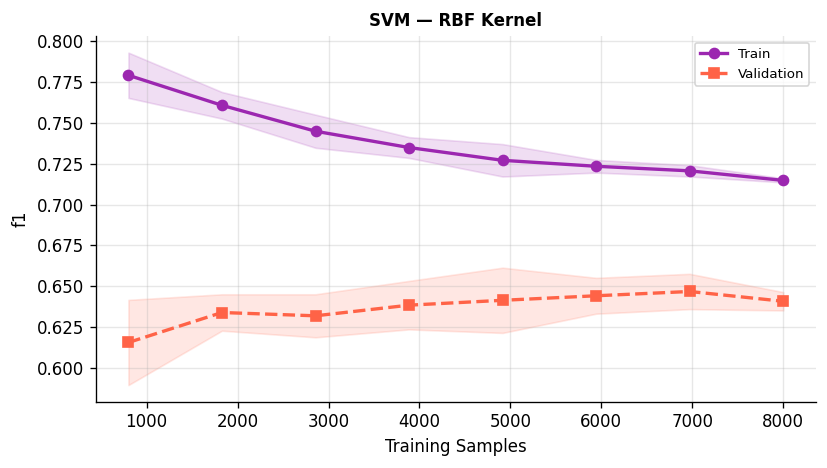

In [11]:
model = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', SVC(kernel='rbf', C=1.0, gamma=0.01, probability=True, random_state=42))
])

fig, ax = plt.subplots(figsize=(7, 4))
plot_learning_curve(ax, model, X_clf_svm, y_clf_svm,
                    title='SVM — RBF Kernel',
                    cv=cv_clf, scoring='f1', color='#9C27B0')
plt.tight_layout()
plt.savefig('figures/lc_svm_rbf.png', bbox_inches='tight')
plt.show()

LC: Decision Tree Classifier

  Train Score (final): 0.6327 ± 0.0107
  Val   Score (final): 0.6253 ± 0.0099
  Gap (overfit):       0.0074


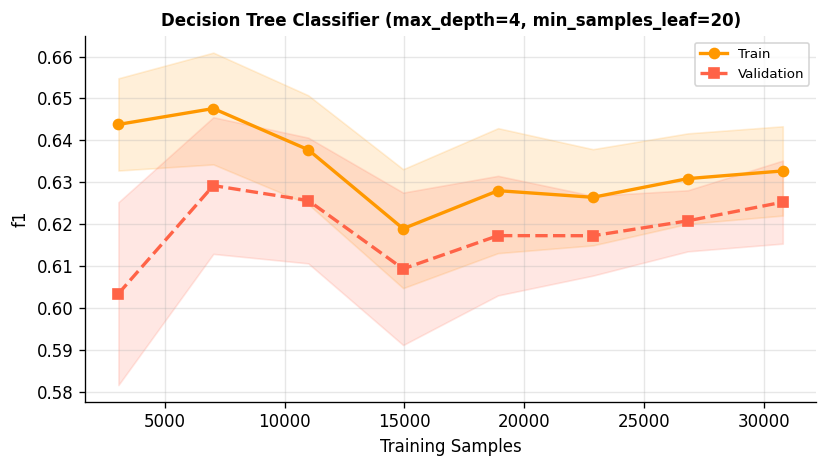

In [12]:
model = DecisionTreeClassifier(max_depth=4, min_samples_leaf=20, random_state=42)

fig, ax = plt.subplots(figsize=(7, 4))
plot_learning_curve(ax, model, X_clf, y_clf,
                    title='Decision Tree Classifier (max_depth=4, min_samples_leaf=20)',
                    cv=cv_clf, scoring='f1', color='#FF9800')
plt.tight_layout()
plt.savefig('figures/lc_decision_tree_clf.png', bbox_inches='tight')
plt.show()

LC: Random Forest Classifier

  Train Score (final): 0.6602 ± 0.0018
  Val   Score (final): 0.6439 ± 0.0053
  Gap (overfit):       0.0163


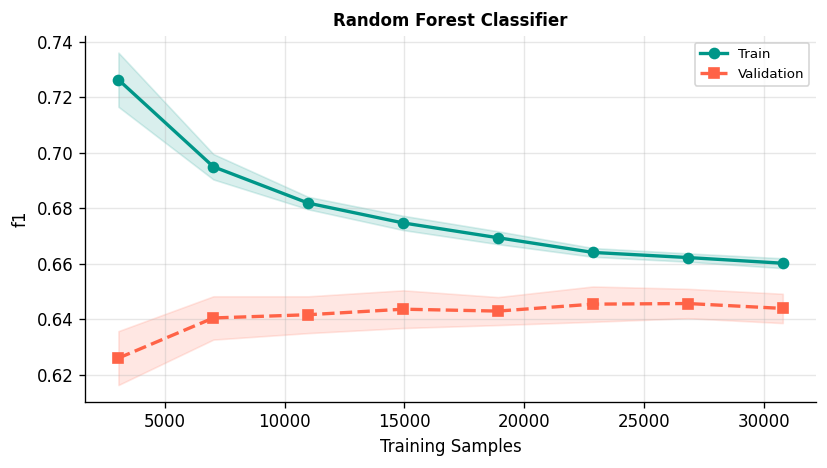

In [13]:
model = RandomForestClassifier(n_estimators=100, max_depth=6, min_samples_leaf=10, random_state=42, n_jobs=-1)

fig, ax = plt.subplots(figsize=(7, 4))
plot_learning_curve(ax, model, X_clf, y_clf,
                    title='Random Forest Classifier',
                    cv=cv_clf, scoring='f1', color='#009688')
plt.tight_layout()
plt.savefig('figures/lc_random_forest_clf.png', bbox_inches='tight')
plt.show()

LC: Gradient Boosting Classifier

  Train Score (final): 0.6973 ± 0.0021
  Val   Score (final): 0.6607 ± 0.0066
  Gap (overfit):       0.0365


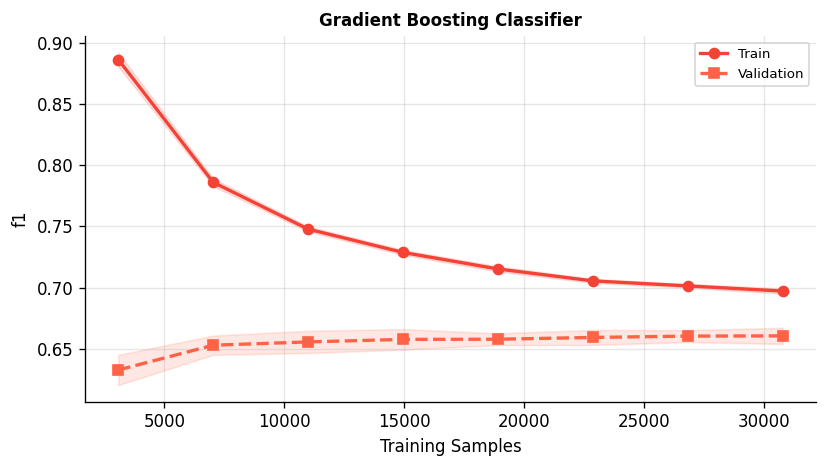

In [14]:
model = GradientBoostingClassifier(n_estimators=200, learning_rate=0.05,max_depth=4,subsample=0.8, random_state=42)

fig, ax = plt.subplots(figsize=(7, 4))
plot_learning_curve(ax, model, X_clf, y_clf,
                    title='Gradient Boosting Classifier',
                    cv=cv_clf, scoring='f1', color='#F44336')
plt.tight_layout()
plt.savefig('figures/lc_gradient_boosting_clf.png', bbox_inches='tight')
plt.show()

LC: XGBoost Classifier

  Train Score (final): 0.6936 ± 0.0018
  Val   Score (final): 0.6614 ± 0.0045
  Gap (overfit):       0.0321


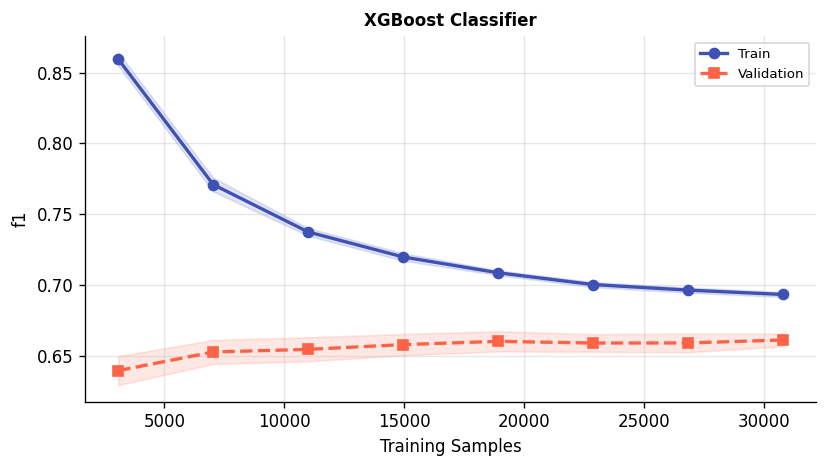

In [15]:
model = XGBClassifier(n_estimators=200, learning_rate=0.05,max_depth=4,subsample=0.8,colsample_bytree=0.8,
                      eval_metric='logloss', random_state=42, n_jobs=-1)

fig, ax = plt.subplots(figsize=(7, 4))
plot_learning_curve(ax, model, X_clf, y_clf,
                    title='XGBoost Classifier',
                    cv=cv_clf, scoring='f1', color='#3F51B5')
plt.tight_layout()
plt.savefig('figures/lc_xgboost_clf.png', bbox_inches='tight')
plt.show()

LC: Linear Regression

  Train Score (final): 0.1385 ± 0.0016
  Val   Score (final): 0.1339 ± 0.0063
  Gap (overfit):       0.0046


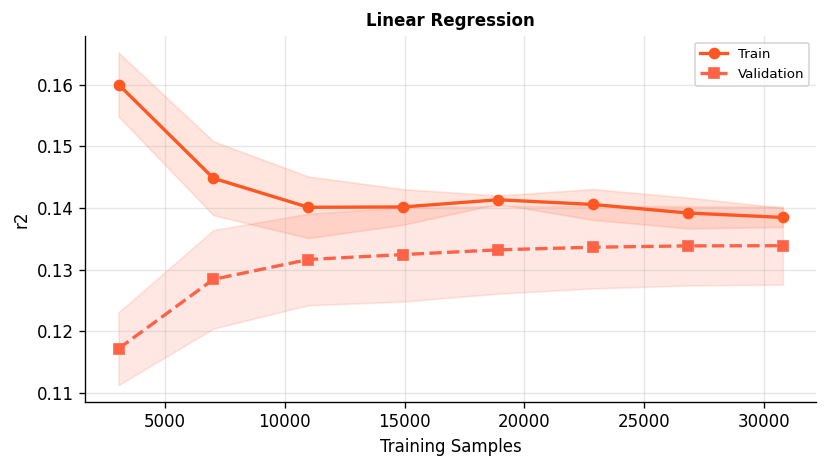

In [16]:
model = Pipeline([
    ('scaler', StandardScaler()),
    ('reg', LinearRegression())
])

fig, ax = plt.subplots(figsize=(7, 4))
plot_learning_curve(ax, model, X_reg, y_reg,
                    title='Linear Regression',
                    cv=cv_reg, scoring='r2', color='#FF5722')
plt.tight_layout()
plt.savefig('figures/lc_linear_regression.png', bbox_inches='tight')
plt.show()

LC: Ridge Regression

  Train Score (final): 0.1385 ± 0.0016
  Val   Score (final): 0.1339 ± 0.0063
  Gap (overfit):       0.0046


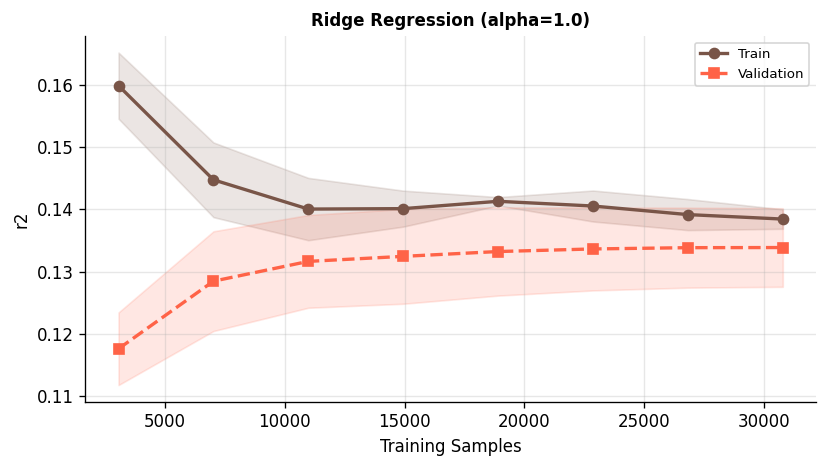

In [17]:
model = Pipeline([
    ('scaler', StandardScaler()),
    ('reg', Ridge(alpha=1.0))
])

fig, ax = plt.subplots(figsize=(7, 4))
plot_learning_curve(ax, model, X_reg, y_reg,
                    title='Ridge Regression (alpha=1.0)',
                    cv=cv_reg, scoring='r2', color='#795548')
plt.tight_layout()
plt.savefig('figures/lc_ridge.png', bbox_inches='tight')
plt.show()

LC: Lasso Regression

  Train Score (final): 0.1268 ± 0.0014
  Val   Score (final): 0.1243 ± 0.0050
  Gap (overfit):       0.0024


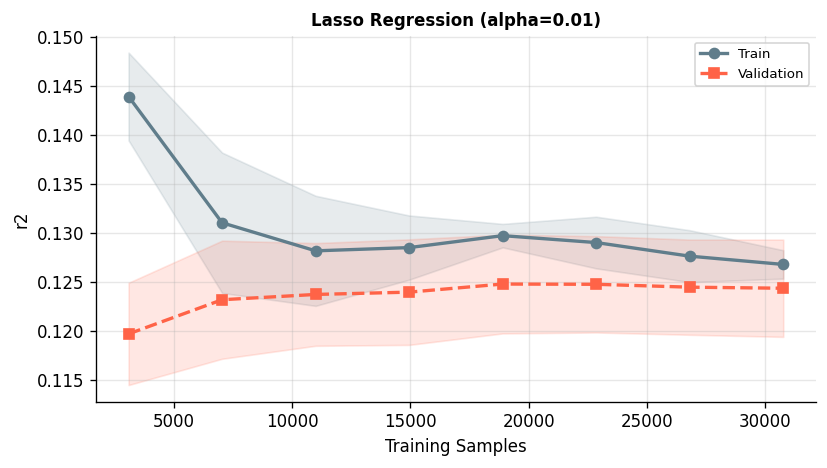

In [18]:
model = Pipeline([
    ('scaler', StandardScaler()),
    ('reg', Lasso(alpha=0.01, max_iter=5000))
])

fig, ax = plt.subplots(figsize=(7, 4))
plot_learning_curve(ax, model, X_reg, y_reg,
                    title='Lasso Regression (alpha=0.01)',
                    cv=cv_reg, scoring='r2', color='#607D8B')
plt.tight_layout()
plt.savefig('figures/lc_lasso.png', bbox_inches='tight')
plt.show()

LC: Elastic Net

  Train Score (final): 0.1327 ± 0.0014
  Val   Score (final): 0.1298 ± 0.0053
  Gap (overfit):       0.0028


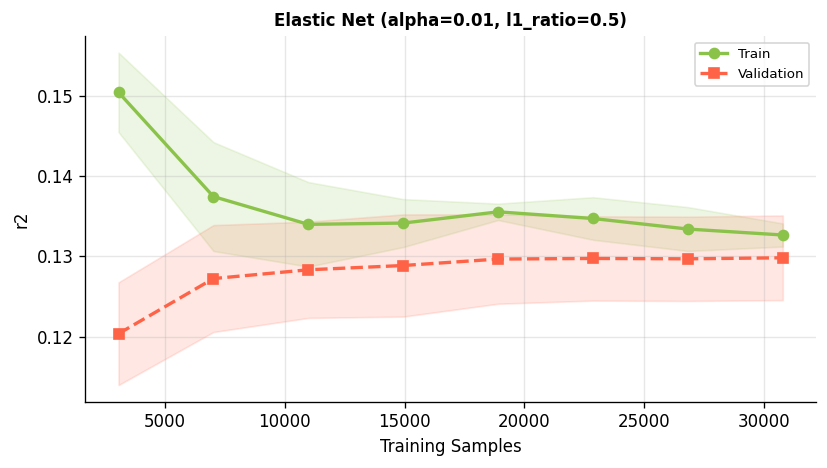

In [19]:
model = Pipeline([
    ('scaler', StandardScaler()),
    ('reg', ElasticNet(alpha=0.01, l1_ratio=0.5, max_iter=5000))
])

fig, ax = plt.subplots(figsize=(7, 4))
plot_learning_curve(ax, model, X_reg, y_reg,
                    title='Elastic Net (alpha=0.01, l1_ratio=0.5)',
                    cv=cv_reg, scoring='r2', color='#8BC34A')
plt.tight_layout()
plt.savefig('figures/lc_elasticnet.png', bbox_inches='tight')
plt.show()

LC: KNN Regressor

  Train Score (final): 0.2117 ± 0.0025
  Val   Score (final): 0.0952 ± 0.0101
  Gap (overfit):       0.1165


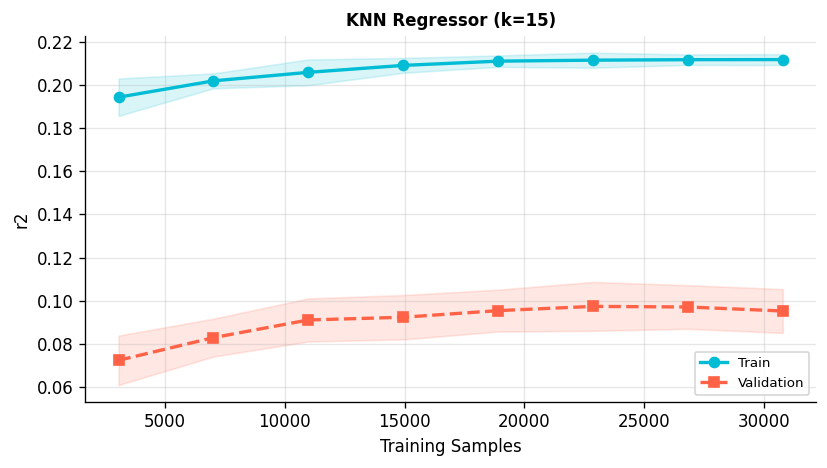

In [20]:
model = Pipeline([
    ('scaler', StandardScaler()),
    ('reg', KNeighborsRegressor(n_neighbors=15))
])

fig, ax = plt.subplots(figsize=(7, 4))
plot_learning_curve(ax, model, X_reg, y_reg,
                    title='KNN Regressor (k=15)',
                    cv=cv_reg, scoring='r2', color='#00BCD4')
plt.tight_layout()
plt.savefig('figures/lc_knn_reg.png', bbox_inches='tight')
plt.show()

In [21]:
# Sample for SVM only — 10k rows
idx_svm = np.random.choice(len(X_reg), 10000, replace=False)
X_reg_svm = X_reg[idx_svm]
y_reg_svm = y_reg[idx_svm]

LC: SVR

  Train Score (final): 0.4054 ± 0.0013
  Val   Score (final): 0.0893 ± 0.0107
  Gap (overfit):       0.3161


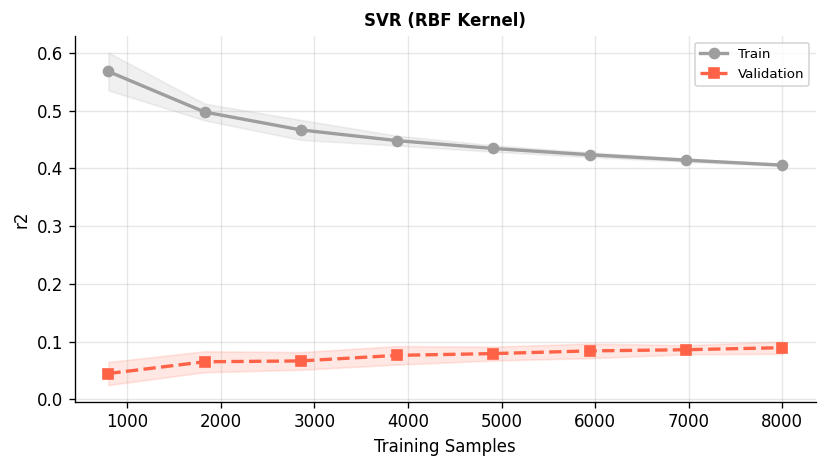

In [22]:
model = Pipeline([
    ('scaler', StandardScaler()),
    ('reg', SVR(kernel='rbf', C=1.0, gamma='scale'))
])

fig, ax = plt.subplots(figsize=(7, 4))
plot_learning_curve(ax, model, X_reg_svm, y_reg_svm,
                    title='SVR (RBF Kernel)',
                    cv=cv_reg, scoring='r2', color='#9E9E9E')
plt.tight_layout()
plt.savefig('figures/lc_svr.png', bbox_inches='tight')
plt.show()

LC: Decision Tree Regressor

  Train Score (final): 0.1090 ± 0.0015
  Val   Score (final): 0.1019 ± 0.0052
  Gap (overfit):       0.0071


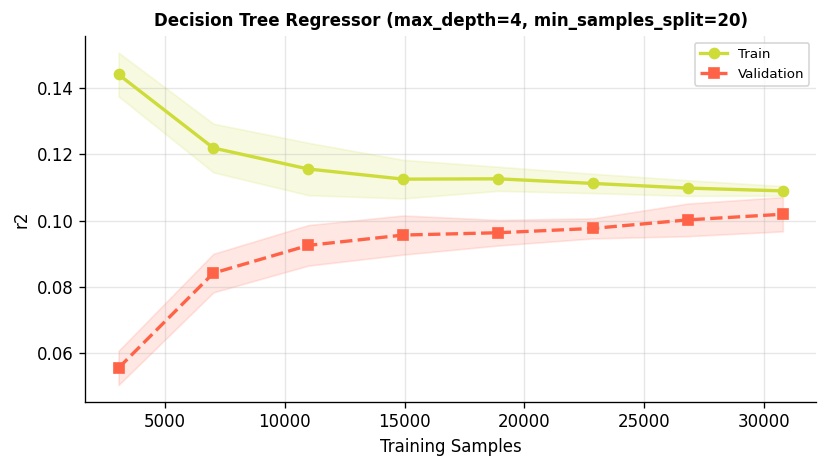

In [23]:
model = DecisionTreeRegressor(max_depth=4, min_samples_leaf=20, random_state=42)

fig, ax = plt.subplots(figsize=(7, 4))
plot_learning_curve(ax, model, X_reg, y_reg,
                    title='Decision Tree Regressor (max_depth=4, min_samples_split=20)',
                    cv=cv_reg, scoring='r2', color='#CDDC39')
plt.tight_layout()
plt.savefig('figures/lc_decision_tree_reg.png', bbox_inches='tight')
plt.show()

LC: Random Forest Regressor

  Train Score (final): 0.1671 ± 0.0021
  Val   Score (final): 0.1345 ± 0.0052
  Gap (overfit):       0.0326


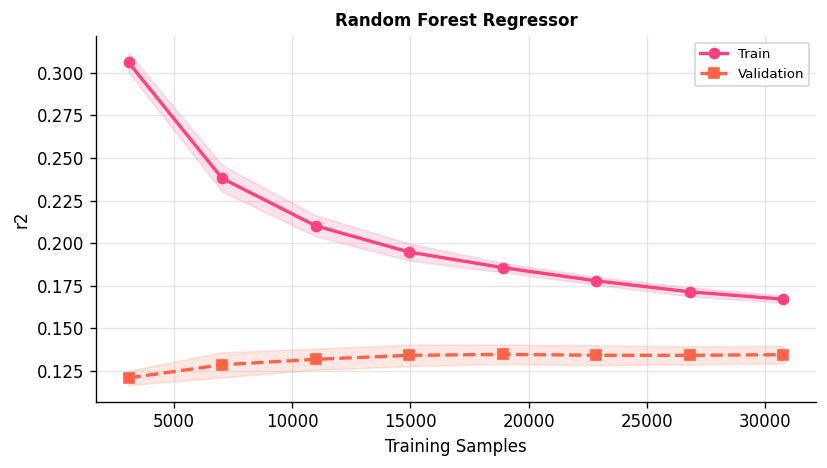

In [ ]:
model = RandomForestRegressor(n_estimators=200, max_depth=8, min_samples_leaf=5,max_features='sqrt', random_state=42, n_jobs=-1)

fig, ax = plt.subplots(figsize=(7, 4))
plot_learning_curve(ax, model, X_reg, y_reg,
                    title='Random Forest Regressor',
                    cv=cv_reg, scoring='r2', color='#FF4081')
plt.tight_layout()
plt.savefig('figures/lc_random_forest_reg.png', bbox_inches='tight')
plt.show()

LC: Gradient Boosting Regressor

  Train Score (final): 0.2424 ± 0.0019
  Val   Score (final): 0.1670 ± 0.0061
  Gap (overfit):       0.0754


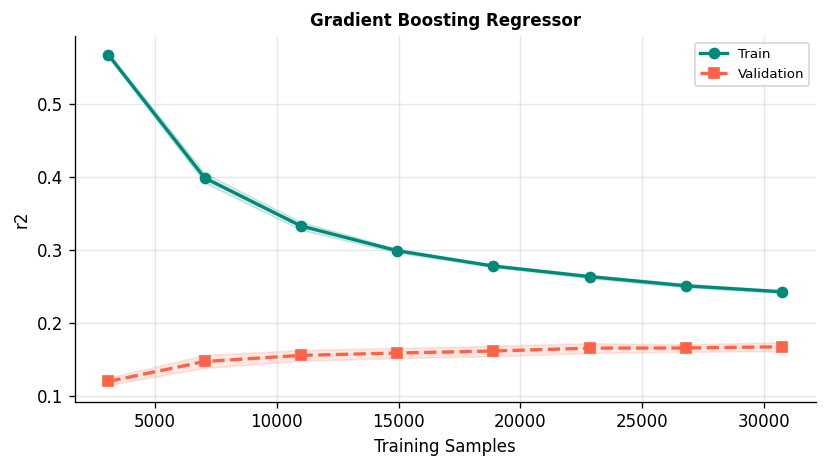

In [25]:
model = GradientBoostingRegressor(n_estimators=200, learning_rate=0.05, max_depth=4, subsample=0.8, random_state=42)

fig, ax = plt.subplots(figsize=(7, 4))
plot_learning_curve(ax, model, X_reg, y_reg,
                    title='Gradient Boosting Regressor',
                    cv=cv_reg, scoring='r2', color='#00897B')
plt.tight_layout()
plt.savefig('figures/lc_gradient_boosting_reg.png', bbox_inches='tight')
plt.show()

LC: XGBoost Regressor

  Train Score (final): 0.2366 ± 0.0014
  Val   Score (final): 0.1684 ± 0.0060
  Gap (overfit):       0.0682


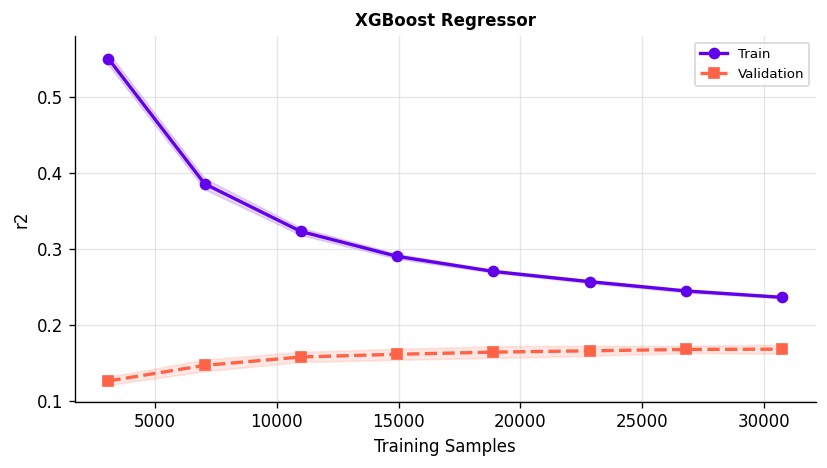

In [28]:
model = XGBRegressor(n_estimators=200, learning_rate=0.05, max_depth=4, subsample=0.8, colsample_bytree=0.8, random_state=42, n_jobs=-1)

fig, ax = plt.subplots(figsize=(7, 4))
plot_learning_curve(ax, model, X_reg, y_reg,
                    title='XGBoost Regressor',
                    cv=cv_reg, scoring='r2', color='#6200EA')
plt.tight_layout()
plt.savefig('figures/lc_xgboost_reg.png', bbox_inches='tight')
plt.show()